In [1]:
%%writefile /tmp/study_dispatch.cpp
extern "C" int dispatch_narrow(int n) {
    int x = n;
    x += x + 1; x += x + 2; x += x + 3; x += x + 4;
    x += x + 5; x += x + 6; x += x + 7; x += x + 8;
    return x;
}
extern "C" int dispatch_wide(int n) {
    int a = n + 1, b = n + 2, c = n + 3, d = n + 4, e = n + 5, f = n + 6;
    a += b; c += d; e += f;
    return a + c + e + n;
}

Overwriting /tmp/study_dispatch.cpp


In [2]:
!g++ -std=c++23 -O3 -c /tmp/study_dispatch.cpp -o /tmp/study_dispatch.o

In [3]:
import pandas as pd

import perf

frames = []
for func in ("dispatch_narrow", "dispatch_wide"):
    df = perf.bench(
        file="/tmp/study_dispatch.o",
        target=func,
        mode="latency",
        event="topdown-retiring,topdown-bad-spec,topdown-fe-bound,topdown-be-bound",
        config={"samples": 60, "runs": 4, "iterations": 300},
        data={"rdi": 7},
    ).reset_index()
    df["func"] = func
    frames.append(df)
top = pd.concat(frames, ignore_index=True)
med = top.groupby("func")[
    ["topdown-retiring", "topdown-bad-spec", "topdown-fe-bound", "topdown-be-bound"]
].median()
pct = med.div(med.sum(axis=1), axis=0).round(3)
print(med.round(1))
print(pct)

                 topdown-retiring  topdown-bad-spec  topdown-fe-bound  \
func                                                                    
dispatch_narrow               9.0               5.0               0.0   
dispatch_wide                10.0               5.0               0.0   

                 topdown-be-bound  
func                               
dispatch_narrow               2.0  
dispatch_wide                 3.0  
                 topdown-retiring  topdown-bad-spec  topdown-fe-bound  \
func                                                                    
dispatch_narrow             0.562             0.312               0.0   
dispatch_wide               0.556             0.278               0.0   

                 topdown-be-bound  
func                               
dispatch_narrow             0.125  
dispatch_wide               0.167  


In [4]:
import pandas as pd

import perf

frames = []
for func in ("dispatch_narrow", "dispatch_wide"):
    df = perf.bench(
        file="/tmp/study_dispatch.o",
        target=func,
        mode="latency",
        event="cycles,instructions,cache-misses",
        config={"samples": 60, "runs": 4, "iterations": 300},
        data={"rdi": 7},
    ).reset_index()
    df["func"] = func
    frames.append(df)
cmp = pd.concat(frames, ignore_index=True)
cmp["ipc"] = cmp["instructions"] / cmp["cycles"]
print(
    cmp.groupby("func")[["cycles", "instructions", "ipc", "cache-misses"]]
    .median()
    .round(2)
)

                 cycles  instructions  ipc  cache-misses
func                                                    
dispatch_narrow     2.0           7.0  3.5           0.0
dispatch_wide       2.0           8.0  4.0           0.0


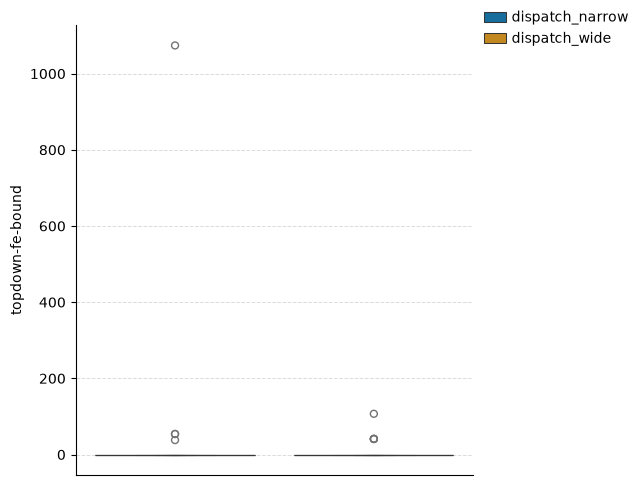

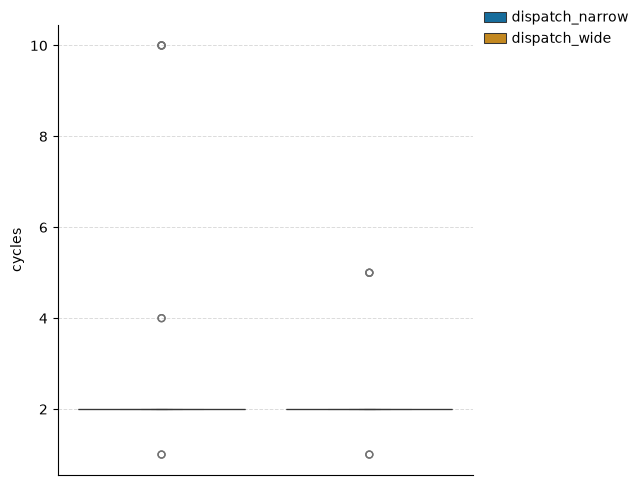

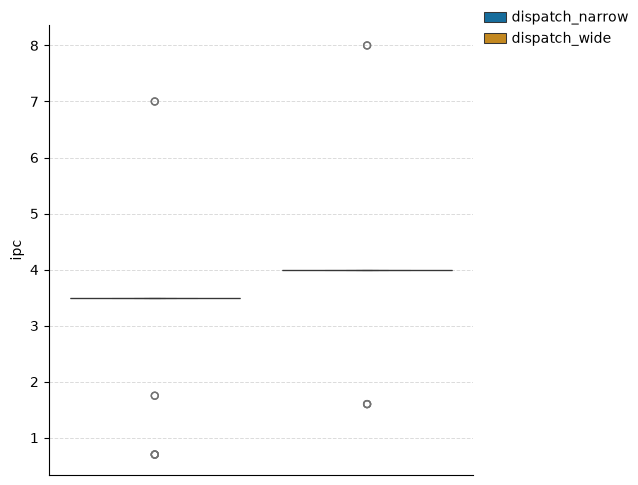

[]

In [5]:
perf.plot(top, "boxen", event="topdown-fe-bound", groupby="func")
perf.plot(cmp, "boxen", event="cycles", groupby="func")
perf.plot(cmp, "boxen", event="ipc", groupby="func")